<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [27]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import requests

### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


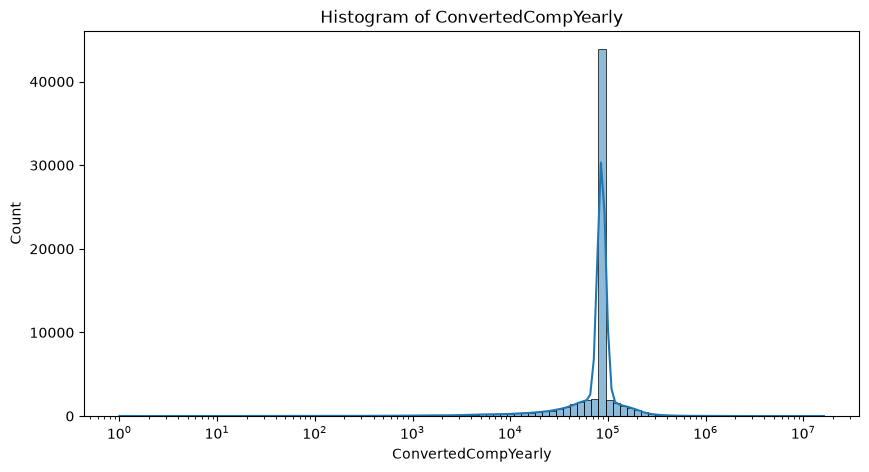

In [21]:
#input missing values with mean value for numerical columns
df.fillna(df.mean(numeric_only=True), inplace=True) 
plt.figure(figsize=(10, 5))
sns.histplot(df['ConvertedCompYearly'], bins=100, kde=True,log_scale=True)
plt.title("Histogram of ConvertedCompYearly")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("Count")
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [25]:
fullemp = df[df['Employment'] == "Employed, full-time"]
medianfullemp = fullemp['ConvertedCompYearly'].median()
print (medianfullemp)

86155.28726264134


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



Country
Bhutan                      3
Monaco                      3
Guinea-Bissau               2
Belize                      2
Mali                        2
Dominica                    1
Papua New Guinea            1
Central African Republic    1
Equatorial Guinea           1
Guinea                      1
Niger                       1
Samoa                       1
Lesotho                     1
Saint Kitts and Nevis       1
Micronesia                  1
Haiti                       1
Nauru                       1
Chad                        1
Djibouti                    1
Solomon Islands             1
Name: count, dtype: int64
<StringArray>
[                   'Kosovo',                    'Taiwan',
               'Isle of Man',                   'Nomadic',
        'Hong Kong (S.A.R.)', 'Eswatini (fmr. Swaziland)',
             'Côte d'Ivoire']
Length: 7, dtype: str
             count          mean           std      min           25%  \
Country                                           

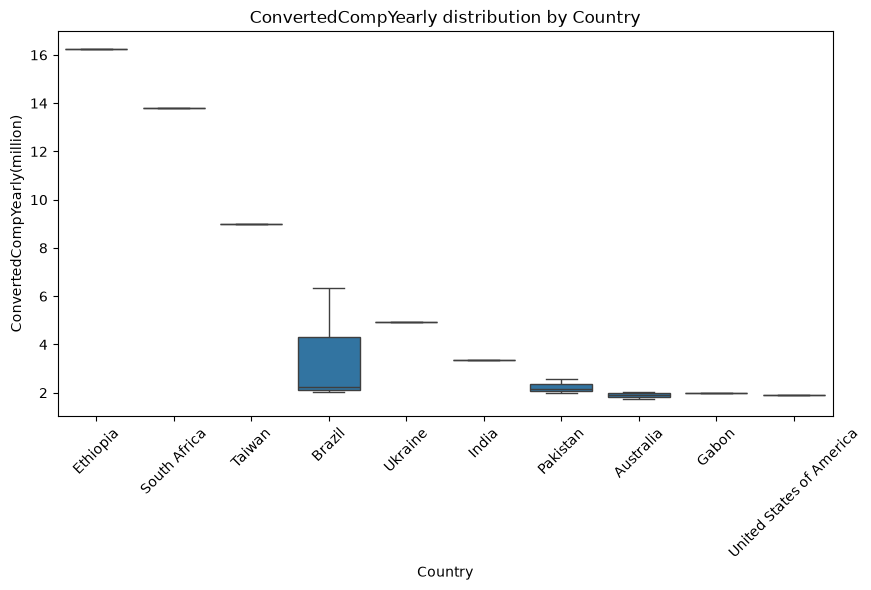

In [85]:
# 1. Spot Variations via Alphabetical Grouping
# Get sorted unique values to manually spot inconsistencies
unique_countries = sorted(df['Country'].dropna().unique())

#2. Finding Typos and Frequency Outliers
# View the least frequent entries in the column
print(df['Country'].value_counts().tail(20))
# Replace 'old_value' with 'new_value'
df['Country'] = df['Country'].replace({"Democratic People's Republic of Korea": "North Korea", "Micronesia, Federated States of...": "Micronesia", "Viet Nam": "Vietnam"})

#3. Detecting Irrelevant Entries using a Reference List

##find valid list of countries to compare against
url = "https://www.worldometers.info/geography/alphabetical-list-of-countries/"

## download webpage at the url
data  = requests.get(url).text 
soup = BeautifulSoup(data,"html.parser")  # create a soup object using the variable 'data'
## scrape countries
table = soup.find('table')
rows = table.find_all('tr') # in html table row is represented by the tag <tr>
## create empty list for valid list of countries in the world
validlist = []
## for each row, append the Country value into the validlist 
for row in rows[1:]: #skip first row (header)
    # Get all columns in each row.
    cols = row.find_all('td') # in html a column is represented by the tag <td>
    Country = cols[1].getText() # store the value in column 2 as Country
    validlist.append(Country)
# Remove spaces from the front and back of each item
cleanvalidlist = [item.strip() for item in validlist]

# Isolate rows where the country is NOT in cleaned valid list of countries
invalid_entry = ~df['Country'].isin(cleanvalidlist)
irrelevant_entries = df[invalid_entry]

print(irrelevant_entries['Country'].unique())

## Replace 'old_value' with 'new_value'
df['Country'] = df['Country'].replace({"United Kingdom of Great Britain and Northern Ireland": "United Kingdom", 
                                       "Iran, Islamic Republic of...": "Iran",
                                      "Czech Republic": "Czechia (Czech Republic)",
                                      "Republic of North Macedonia": "North Macedonia", 
                                      "Russian Federation": "Russia", 
                                      "United Republic of Tanzania": "Tanzania", 
                                        "Venezuela, Bolivarian Republic of...": "Venezuela",
                                       "Myanmar": "Myanmar (formerly Burma)",
                                       "Republic of Korea": "South Korea",
                                       "Republic of Moldova": "Moldova",
                                       "Palestine": "Palestine State",
                                       "Lao People's Democratic Republic": "Laos",
                                       "Syrian Arab Republic": "Syria",
                                       "Swaziland": "Eswatini (fmr. ""Swaziland"")",
                                       "Côte d'Ivoire": "Côte d'Ivoire",
                                       "Congo, Republic of the...": "Congo (Congo-Brazzaville)",
                                       "Libyan Arab Jamahiriya": "Libya",
                                       "Cape Verde": "Cabo Verde",
                                       "Brunei Darussalam": "Brunei",
                                       "Eswatini (fmr. Swaziland)": "Eswatini (fmr. ""Swaziland"")"
                                      })

#drop rows with missing values in Country column
df = df.dropna(subset=['Country'])

# Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean
df.fillna(df.mean(numeric_only=True), inplace=True)

#Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value
# Select only categorical columns
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns
# Loop and fill with each column's most frequent value df['col'].mode()[0]
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print (df.groupby('Country')['ConvertedCompYearly'].describe())
# keep only rows with both country and compensation. choose only top 15 countries
countrycomp = df[['Country', 'ConvertedCompYearly']].sort_values('ConvertedCompYearly', ascending=False).head(15)
countrycomp['ConvertedCompYearly(million)'] = countrycomp['ConvertedCompYearly'] / 1000000
plt.figure(figsize=(10, 5))
sns.boxplot(data=countrycomp, x='Country', y='ConvertedCompYearly(million)')
plt.title("ConvertedCompYearly distribution by Country")
plt.xticks(rotation=45)
plt.show()


<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [86]:
print(df['ConvertedCompYearly'].describe())
#Outliers
exceedd = df[df['ConvertedCompYearly'] > 1.625660e+07]
print ("Outlier that exceed max:", exceedd['ConvertedCompYearly'])
below = df[df['ConvertedCompYearly'] < 1.000000e+00]
print ("Outlier below min:", below['ConvertedCompYearly'])
#Nil outliers below min

#remove outliers
new_df = df[df['ConvertedCompYearly'] <= 1.625660e+07]

count    5.893000e+04
mean     8.615529e+04
std      1.177702e+05
min      1.000000e+00
25%      8.500000e+04
50%      8.615529e+04
75%      8.615529e+04
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64
Outlier that exceed max: 15837    16256603.0
Name: ConvertedCompYearly, dtype: float64
Outlier below min: Series([], Name: ConvertedCompYearly, dtype: float64)


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


Correlation of ConvertedCompYearly and WorkExp: 0.10199402593701022
Correlation of ConvertedCompYearly and JobSatPoints_1: 0.013555949073820283


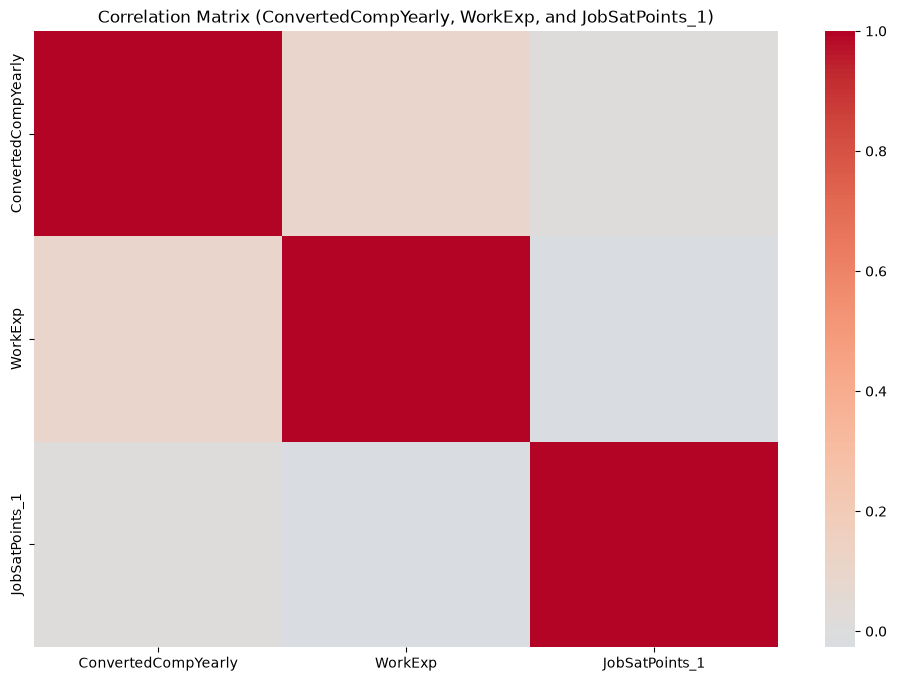

In [89]:
# correlations
for param in ['WorkExp', 'JobSatPoints_1']:
    corr = new_df[['ConvertedCompYearly', param]].corr().loc['ConvertedCompYearly', param]
    print(f"Correlation of ConvertedCompYearly and {param}: {corr}") #returns pearson coefficient

cols = ['ConvertedCompYearly'] + ['WorkExp', 'JobSatPoints_1']

corr_matrix = new_df[cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Matrix (ConvertedCompYearly, WorkExp, and JobSatPoints_1)")
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


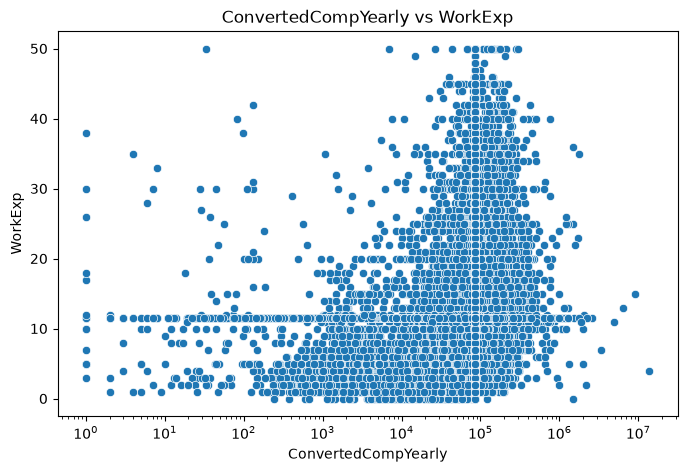

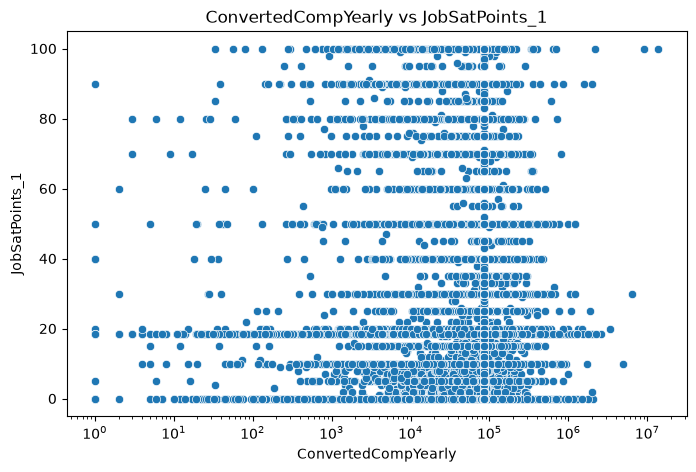

In [95]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=new_df, x="ConvertedCompYearly", y="WorkExp")
plt.xscale("log")
plt.title("ConvertedCompYearly vs WorkExp")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("WorkExp")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=new_df, x="ConvertedCompYearly", y="JobSatPoints_1")
plt.xscale("log")
plt.title("ConvertedCompYearly vs JobSatPoints_1")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("JobSatPoints_1")
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
